In [1]:
from __future__ import annotations
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_moons, make_classification, make_blobs
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score, recall_score, accuracy_score
import seaborn as sns
import pandas as pd
import sys

sys.path.append('..')
from evaluation_functions import print_metrics, plot_decision_boundary, plot_roc, plot_confusion_matrix, measure_fit_time, ClassifierAbstraction

# Preparing synthetic data

In [2]:
RANDOM_STATE = 264034
N_SAMPLES = 2634

[0 1 2 3]


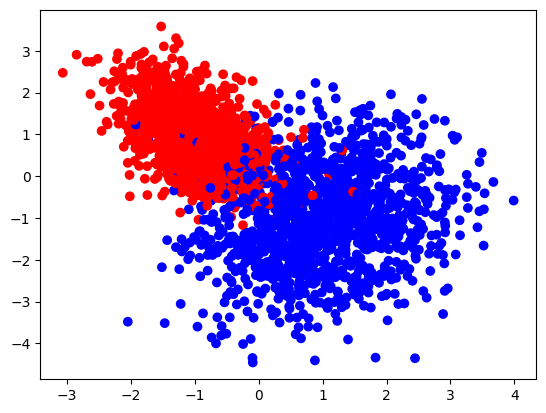

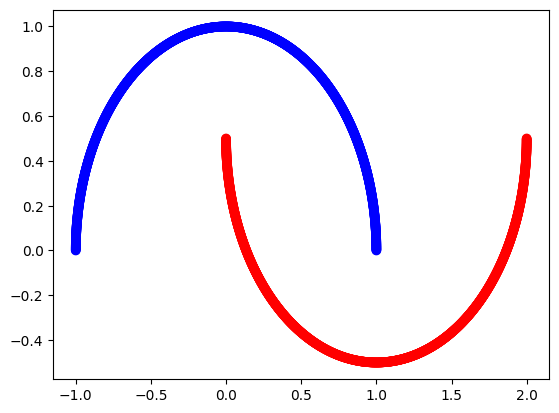

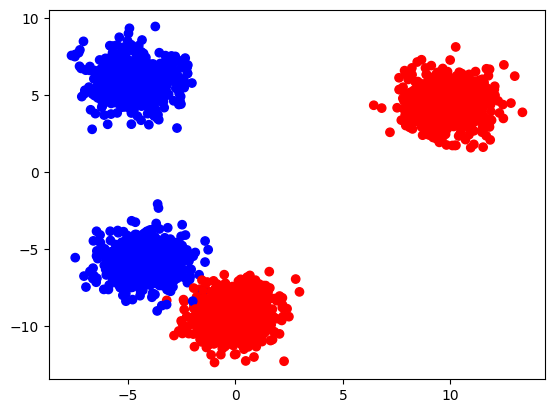

In [3]:
X_classification, y_classification = make_classification(n_samples = N_SAMPLES, n_clusters_per_class=1, n_features = 2, n_redundant = 0, n_informative = 2, random_state = RANDOM_STATE)
X_moons, y_moons = make_moons(n_samples = N_SAMPLES, random_state = RANDOM_STATE, noise=0)
X_multi_claster, y_multi_claster = make_blobs(n_samples = N_SAMPLES, random_state = RANDOM_STATE, n_features=2, centers=4) # type: ignore

print(np.unique(y_multi_claster))
y_multi_claster = np.where( y_multi_claster > 1 , 1, 0)

plt.scatter(X_classification[:, 0], X_classification[:, 1], c=y_classification, cmap="bwr")
plt.show()
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap="bwr")
plt.show()
plt.scatter(X_multi_claster[:,0], X_multi_claster[:,1], c=y_multi_claster, cmap="bwr")
plt.show()

________

# Implementation of random forest

## Gini score functions

In [4]:
def gini(Y : np.ndarray):
    n_samples = len(Y)
    _, classes_counts = np.unique(Y, return_counts=True)
    probabilities = classes_counts / n_samples
    gini_score = 1 - np.sum(probabilities ** 2)
    return gini_score
        

def split_info_gain(Y : np.ndarray, left_mask : np.ndarray):
    right_mask = np.logical_not(left_mask)
    n = len(Y)
    n_left, n_right = left_mask.sum(), right_mask.sum()

    if n_left == 0 or n_right == 0:
        return 0.0

    gain = gini(Y)
    gain -= (n_left / n) * gini(Y[left_mask])
    gain -= (n_right / n) * gini(Y[right_mask])
    return gain


def best_split(X : np.ndarray, Y : np.ndarray, n_percentiles = 20, max_features = None):
    n_sample, n_features = X.shape
    best_gain = -np.inf
    best_feature, best_threshold = None, None

    if max_features is None:
        max_features = int(np.sqrt(n_features))

    features = np.random.choice(n_features, max_features, replace=False)

    for feature_idx in features:
        col = X[:, feature_idx]
        thresholds = np.percentile(col, np.linspace(0, 100, n_percentiles + 2)[1:-1])

        for threshold in thresholds:
            left_mask = X[:, feature_idx] <= threshold
            gain = split_info_gain(Y, left_mask)

            if gain > best_gain:
                best_gain = gain
                best_feature = feature_idx
                best_threshold = threshold

    return best_feature, best_threshold, best_gain

y = np.array([1,1,1,1,0,0,0])
gini(y)

np.float64(0.48979591836734704)

In [5]:
@dataclass
class Node:
    is_leaf: bool = False
    prediction: int | None = None
    feature: int | None = None
    threshold: float | None = None
    left_child: Node | None = None
    right_child: Node | None = None


## Decision tree

In [6]:
class DecisionTree(ClassifierAbstraction):
    def __init__(self, max_depth : int | None = None, n_percentiles : int = 20, max_features = None) -> None:
        self.max_depth = max_depth
        self.n_percentiles = n_percentiles
        self.root = None
        self.max_features = max_features

    def _majority(self, y: np.ndarray) -> int:
        return int(np.bincount(y).argmax())

    def _build(self, X: np.ndarray, y: np.ndarray, depth: int) -> Node:
        if len(np.unique(y)) == 1 or (self.max_depth is not None and depth >= self.max_depth):
            return Node(is_leaf=True, prediction=self._majority(y))
        
        feature, threshold, gain = best_split(X, y, self.n_percentiles, self.max_features)

        if gain <= 0 or feature is None:
            return Node(is_leaf=True, prediction=self._majority(y))

        mask = X[:, feature] <= threshold
        bitwise_not_mask = np.logical_not(mask)
        return Node(
            feature=feature, threshold=threshold,
            left_child=self._build(X[mask], y[mask], depth=depth+1),
            right_child=self._build(X[bitwise_not_mask], y[bitwise_not_mask], depth=depth+1)
        )

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self.root = self._build(X, y.astype(int), depth=0)

    def _traverse(self, x: np.ndarray, node: Node | None) -> int:
        if node is None:
            return 0
        if node.is_leaf and node.prediction is not None:
            return node.prediction
        if x[node.feature] <= node.threshold:
            return self._traverse(x, node.left_child)
        return self._traverse(x, node.right_child)

    def predict(self, X: np.ndarray) -> np.ndarray:
        return np.array([self._traverse(x, self.root) for x in X])

    def decision_function(self, X: np.ndarray) -> np.ndarray:
        return self.predict(X).astype(float)
    


## Random forest implementation

In [7]:
class RandomForest(ClassifierAbstraction):
    def __init__(self, n_trees=100, max_depth=None, max_features=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.max_features = max_features
        self.trees : list[DecisionTree] = []

    def _bootstrap(self, X, y):
        n = len(X)
        indices = np.random.choice(n, n, replace=True)
        oob_mask = np.ones(n, dtype=bool)
        oob_mask[indices] = False
        return X[indices], y[indices], oob_mask

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        n_samples, n_features = X.shape

        oob_votes = np.zeros((n_samples, len(np.unique(y))), dtype=int)
        oob_counts = np.zeros(n_samples, dtype=int)

        for _ in range(self.n_trees):
            X_sample, y_sample, oob_mask = self._bootstrap(X, y)
            dst = DecisionTree(max_depth=self.max_depth, max_features=self.max_features)
            dst.fit(X_sample, y_sample)
            self.trees.append(dst)

            if oob_mask.sum() > 0:
                oob_preds = dst.predict(X[oob_mask])
                oob_votes[oob_mask, oob_preds] += 1
                oob_counts[oob_mask] += 1

        valid = oob_counts > 0
        if valid.sum() == 0:
            self.oob_score_ = None
        else:
            oob_decisions = np.argmax(oob_votes[valid], axis=1)
            self.oob_score_ = accuracy_score(y[valid], oob_decisions)

    def predict(self, X) -> np.ndarray:
        preds = [tree.predict(X) for tree in self.trees]
        return np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=preds)
    
    def decision_function(self, X: np.ndarray) -> np.ndarray:
        preds = np.array([tree.predict(X) for tree in self.trees])
        return preds.mean(axis=0)

____________________

# Testing on synthetic data

## Fit time

In [8]:
# my_dtc = RandomForest()
# sk_dtc = RandomForestClassifier()

# X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
#     X_classification, y_classification, test_size=0.3, random_state=RANDOM_STATE)

# print(f"Sklearn Random Forest mean fit time for 100 runs:  {measure_fit_time(sk_dtc, X_train_clf, y_train_clf)}")
# print(f"My Random Forest mean fit time for 100 runs:       {measure_fit_time(my_dtc, X_train_clf, y_train_clf)}")

## Moons dataset


── My Random Forest ──
Confusion matrix:
[[396   0]
 [  0 395]]
Accuracy:       1.0
Recall:         1.0
Specificity:    1.0

── Sklearn Random Forest ──
Confusion matrix:
[[396   0]
 [  0 395]]
Accuracy:       1.0
Recall:         1.0
Specificity:    1.0


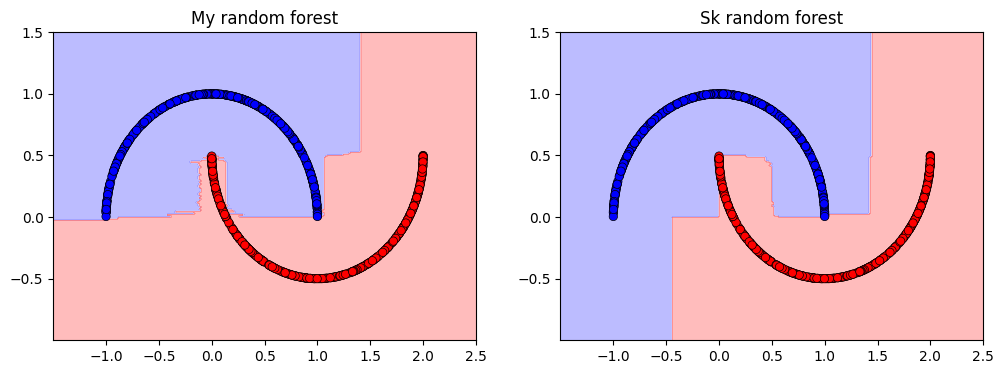

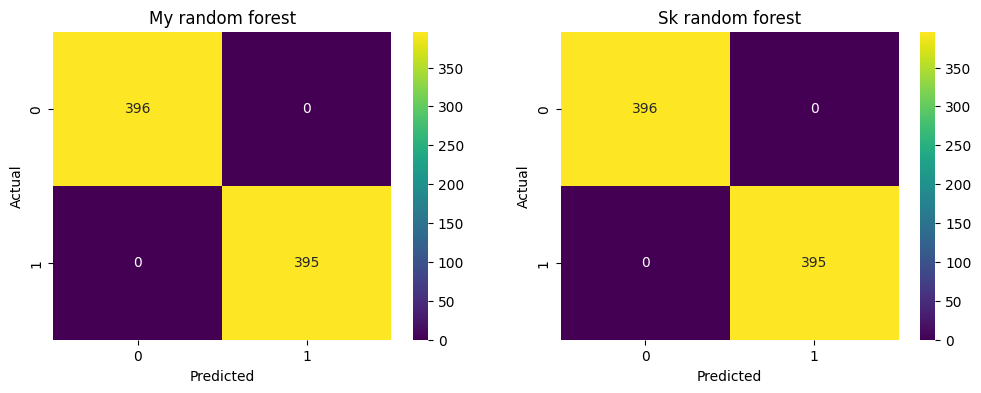

In [9]:
X_train_moons, X_test_moons, y_train_moons, y_test_moons = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=RANDOM_STATE, stratify=y_moons)


my_random_forest = RandomForest()
sk_random_forest = RandomForestClassifier()

my_random_forest.fit(X_train_moons, y_train_moons)
sk_random_forest.fit(X_train_moons, y_train_moons)

print_metrics(my_random_forest, X_test_moons, y_test_moons, "My Random Forest")
print_metrics(sk_random_forest, X_test_moons, y_test_moons, "Sklearn Random Forest")

fig, axes = plt.subplots(1, 2, figsize = (12, 4))
plot_decision_boundary(my_random_forest, X_test_moons, y_test_moons, axes[0], "My random forest")
plot_decision_boundary(sk_random_forest, X_test_moons, y_test_moons, axes[1], "Sk random forest")
plt.show()

fig, axes = plt.subplots(1, 2, figsize = (12, 4))
plot_confusion_matrix(my_random_forest, X_test_moons, y_test_moons, axes[0], title = "My random forest")
plot_confusion_matrix(sk_random_forest, X_test_moons, y_test_moons, axes[1], title = "Sk random forest")
plt.show()

## Classification dataset


── My Random Forest ──
Confusion matrix:
[[369  27]
 [ 12 383]]
Accuracy:       0.9506953223767383
Recall:         0.9696202531645569
Specificity:    0.9318181818181818

── Sklearn Random Forest ──
Confusion matrix:
[[368  28]
 [ 15 380]]
Accuracy:       0.9456384323640961
Recall:         0.9620253164556962
Specificity:    0.9292929292929293


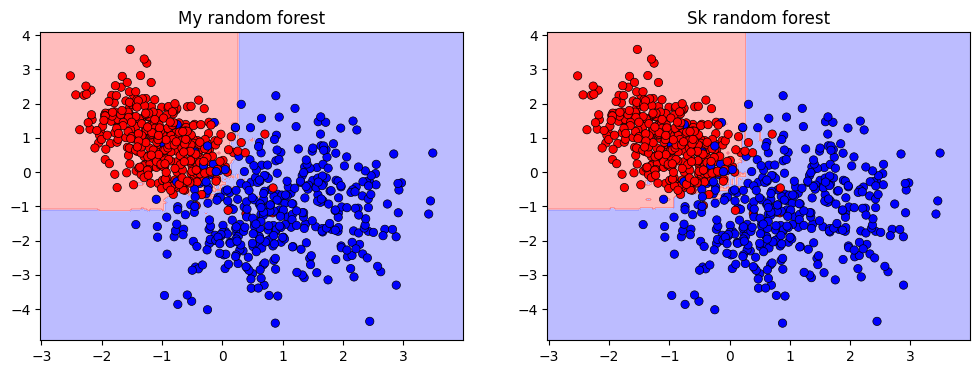

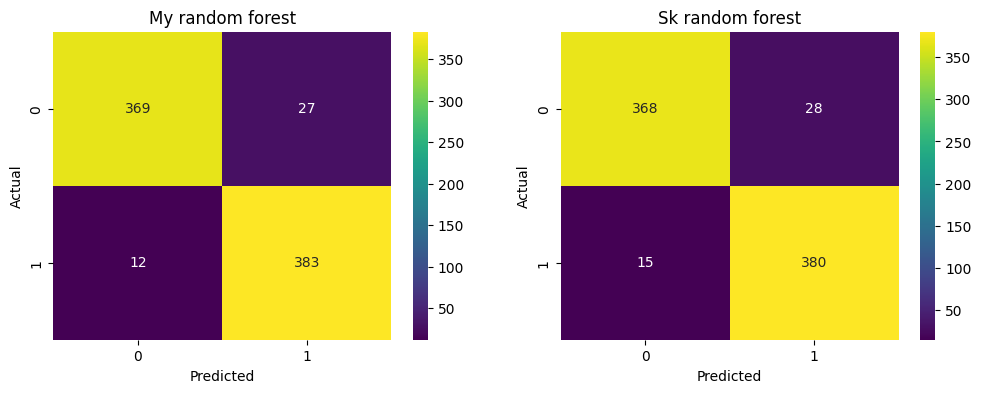

In [10]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_classification, y_classification, test_size=0.3, random_state=RANDOM_STATE, stratify= y_classification)

my_random_forest = RandomForest()
sk_random_forest = RandomForestClassifier()

my_random_forest.fit(X_train_clf, y_train_clf)
sk_random_forest.fit(X_train_clf, y_train_clf)

print_metrics(my_random_forest, X_test_clf, y_test_clf, "My Random Forest")
print_metrics(sk_random_forest, X_test_clf, y_test_clf, "Sklearn Random Forest")

fig, axes = plt.subplots(1, 2, figsize = (12, 4))
plot_decision_boundary(my_random_forest, X_test_clf, y_test_clf, axes[0], "My random forest")
plot_decision_boundary(sk_random_forest, X_test_clf, y_test_clf, axes[1], "Sk random forest")
plt.show()

fig, axes = plt.subplots(1, 2, figsize = (12, 4))
plot_confusion_matrix(my_random_forest, X_test_clf, y_test_clf, axes[0], title = "My random forest")
plot_confusion_matrix(sk_random_forest, X_test_clf, y_test_clf, axes[1], title = "Sk random forest")
plt.show()

## Blobs dataset


── My Random Forest ──
Confusion matrix:
[[395   1]
 [  0 395]]
Accuracy:       0.9987357774968394
Recall:         1.0
Specificity:    0.9974747474747475

── Sklearn Random Forest ──
Confusion matrix:
[[395   1]
 [  1 394]]
Accuracy:       0.9974715549936789
Recall:         0.9974683544303797
Specificity:    0.9974747474747475


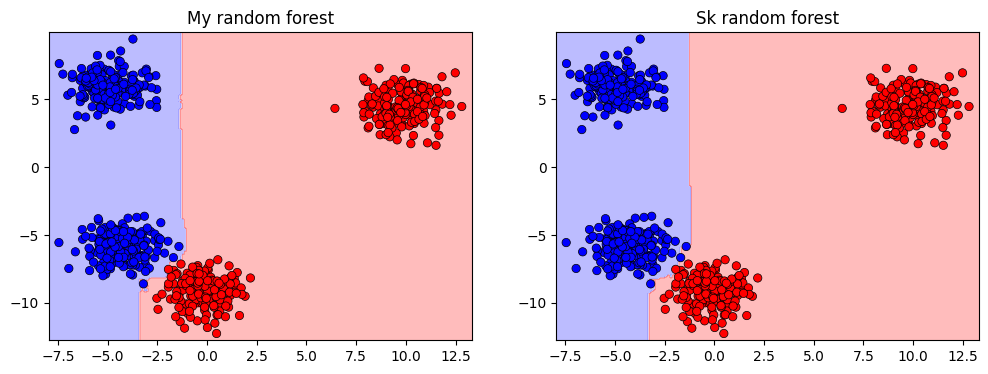

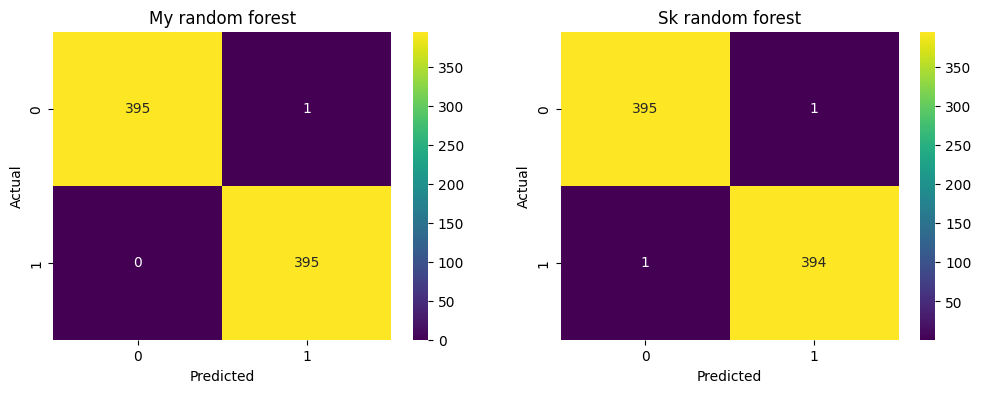

In [11]:
X_train_blobs, X_test_blobs, y_train_blobs, y_test_blobs = train_test_split(
    X_multi_claster, y_multi_claster, test_size=0.3, random_state=RANDOM_STATE, stratify=y_multi_claster)

my_random_forest = RandomForest()
sk_random_forest = RandomForestClassifier()

my_random_forest.fit(X_train_blobs, y_train_blobs)
sk_random_forest.fit(X_train_blobs, y_train_blobs)

print_metrics(my_random_forest, X_test_blobs, y_test_blobs, "My Random Forest")
print_metrics(sk_random_forest, X_test_blobs, y_test_blobs, "Sklearn Random Forest")

fig, axes = plt.subplots(1, 2, figsize = (12, 4))
plot_decision_boundary(my_random_forest, X_test_blobs, y_test_blobs, axes[0], "My random forest")
plot_decision_boundary(sk_random_forest, X_test_blobs, y_test_blobs, axes[1], "Sk random forest")
plt.show()

fig, axes = plt.subplots(1, 2, figsize = (12, 4))
plot_confusion_matrix(my_random_forest, X_test_blobs, y_test_blobs, axes[0], title = "My random forest")
plot_confusion_matrix(sk_random_forest, X_test_blobs, y_test_blobs, axes[1], title = "Sk random forest")
plt.show()

## Finding optimal depth using OOB error

In [12]:
from tqdm import tqdm

100%|██████████| 30/30 [00:52<00:00,  1.73s/it]


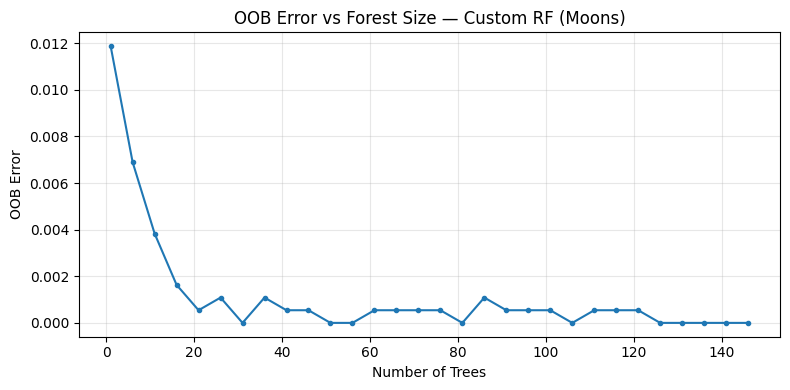

In [13]:
# OOB curve on synthetic data using YOUR implementation
oob_errors = []
tree_counts = list(range(1, 150, 5))

for n in tqdm(tree_counts):
    rf = RandomForest(n_trees=n, max_depth=None)
    rf.fit(X_train_moons, y_train_moons)
    if rf.oob_score_ is not None:
        oob_errors.append(1 - rf.oob_score_)

plt.figure(figsize=(8, 4))
plt.plot(tree_counts, oob_errors, marker='o', markersize=3)
plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.title("OOB Error vs Forest Size — Custom RF (Moons)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
optimal_idx = np.argmin(oob_errors)
optimal_n = tree_counts[optimal_idx]
print(f"Chosen n_estimators based on min OOB error: {optimal_n} (OOB error: {oob_errors[optimal_idx]:.4f})")

Chosen n_estimators based on min OOB error: 31 (OOB error: 0.0000)


_________________________

# Real dataset test

## Importing data

In [15]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sakhawat18/asteroid-dataset")

print("Path to dataset files:", path)

df = pd.read_csv(f"{path}\\dataset.csv")

c:\Users\MatG\Desktop\UniStuff\MAGI\Podstawy uczenia maszynowego\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\MatG\.cache\kagglehub\datasets\sakhawat18\asteroid-dataset\versions\295


C:\Users\MatG\AppData\Local\Temp\ipykernel_12828\4161343208.py:8: DtypeWarning: Columns (0: pdes, 1: name, 2: prefix) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{path}\\dataset.csv")


## Preprocessing

In [16]:
df.head(5)

,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


In [17]:
df.columns

Index(['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'H',
       'diameter', 'albedo', 'diameter_sigma', 'orbit_id', 'epoch',
       'epoch_mjd', 'epoch_cal', 'equinox', 'e', 'a', 'q', 'i', 'om', 'w',
       'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld',
       'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w',
       'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class',
       'rms'],
      dtype='str')

dropping columns irrelevant to prediction

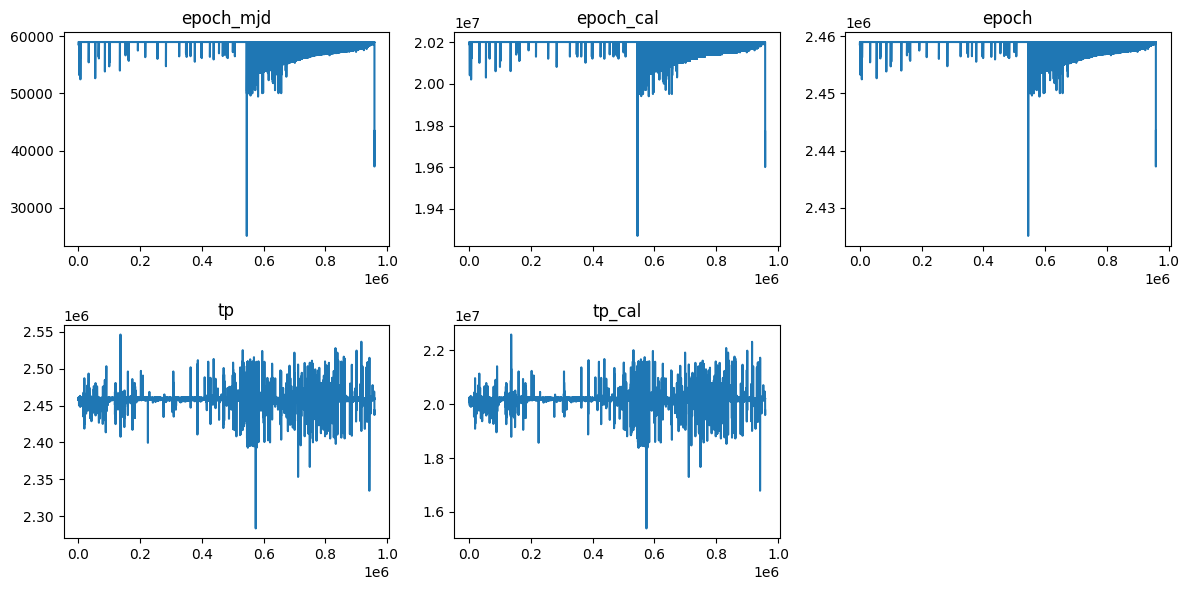

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

axes[0].plot(df['epoch_mjd'])
axes[0].set_title('epoch_mjd')

axes[1].plot(df['epoch_cal'])
axes[1].set_title('epoch_cal')

axes[2].plot(df['epoch'])
axes[2].set_title('epoch')

axes[3].plot(df['tp'])
axes[3].set_title('tp')

axes[4].plot(df['tp_cal'])
axes[4].set_title('tp_cal')
axes[5].axis('off')

plt.tight_layout()
plt.show()

In [19]:
redundant_date_columns = ['epoch_cal', 'tp_cal', 'epoch']

In [20]:
sigma_columns = df.columns[df.columns.str.startswith('sigma')].to_list()
sigma_columns

['sigma_e',
 'sigma_a',
 'sigma_q',
 'sigma_i',
 'sigma_om',
 'sigma_w',
 'sigma_ma',
 'sigma_ad',
 'sigma_n',
 'sigma_tp',
 'sigma_per']

In [21]:
irrelevant_columns = ['id', 'spkid', 'full_name', 'orbit_id', 'pdes', 'equinox', 'per_y', 'moid_ld'] + sigma_columns + redundant_date_columns

In [22]:
df = df.drop(columns = irrelevant_columns)

In [23]:
df.head(2)

,name,prefix,neo,pha,H,diameter,albedo,diameter_sigma,epoch_mjd,e,...,om,w,ma,ad,n,tp,per,moid,class,rms
0,Ceres,NaN,N,N,3.4,939.4,0.090,0.2,58600,0.076009,...,80.305531,73.597695,77.372098,2.979647,0.213885,2.458239e+06,1683.145703,1.59478,MBA,0.43301
1,Pallas,NaN,N,N,4.2,545.0,0.101,18.0,59000,0.229972,...,173.024741,310.202392,144.975675,3.411748,0.213345,2.458321e+06,1687.410992,1.23429,MBA,0.35936


In [24]:
df.columns

Index(['name', 'prefix', 'neo', 'pha', 'H', 'diameter', 'albedo',
       'diameter_sigma', 'epoch_mjd', 'e', 'a', 'q', 'i', 'om', 'w', 'ma',
       'ad', 'n', 'tp', 'per', 'moid', 'class', 'rms'],
      dtype='str')

In [25]:
df = df.drop(columns = 'class') # droping class column entirely as the classes to predict are NEO and PHA

droping and filling missing data

In [26]:
missing_percentages = (df.isna().sum() / len(df) * 100)
# missing_percentages

In [27]:
missing_percentages[missing_percentages > 30]

name              97.698128
prefix            99.998122
diameter          85.789714
albedo            85.905100
diameter_sigma    85.803068
dtype: float64

In [28]:
columns_missing_too_much_data = missing_percentages[missing_percentages > 30].index.tolist()
columns_missing_too_much_data

['name', 'prefix', 'diameter', 'albedo', 'diameter_sigma']

In [29]:
df = df.drop(columns=columns_missing_too_much_data)

In [30]:
df.head(2)

,neo,pha,H,epoch_mjd,e,a,q,i,om,w,ma,ad,n,tp,per,moid,rms
0,N,N,3.4,58600,0.076009,2.769165,2.558684,10.594067,80.305531,73.597695,77.372098,2.979647,0.213885,2.458239e+06,1683.145703,1.59478,0.43301
1,N,N,4.2,59000,0.229972,2.773841,2.135935,34.832932,173.024741,310.202392,144.975675,3.411748,0.213345,2.458321e+06,1687.410992,1.23429,0.35936


In [31]:
missing_percentages = (df.isna().sum() / len(df) * 100)
missing_percentages[missing_percentages > 0]

neo     0.000417
pha     2.078300
H       0.653400
ma      0.000104
ad      0.000417
per     0.000417
moid    2.078300
rms     0.000209
dtype: float64

In [32]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

cat_cols

Index(['neo', 'pha'], dtype='str')

In [33]:
# fill numeric with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# fill categorical with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode().iloc[0])

changing categorical into numerical for my model

In [34]:
df['neo'] = df['neo'].map({'Y': 1, 'N': 0})
df['pha'] = df['pha'].map({'Y': 1, 'N': 0})

In [35]:
df['pha'].unique()

array([0, 1])

In [36]:
df.isna().sum()

neo          0
pha          0
H            0
epoch_mjd    0
e            0
a            0
q            0
i            0
om           0
w            0
ma           0
ad           0
n            0
tp           0
per          0
moid         0
rms          0
dtype: int64

## Preparing datasets

In [37]:
X_neo = df.drop(columns=['neo', 'pha'])
y_neo = df['neo']

In [38]:
X_pha = df.drop(columns=['neo', 'pha'])
y_pha = df['pha']

In [39]:
X_train_neo, X_test_neo, y_train_neo, y_test_neo = train_test_split(
    X_neo, y_neo, test_size=0.3, random_state=RANDOM_STATE, stratify=y_neo
)

X_train_pha, X_test_pha, y_train_pha, y_test_pha = train_test_split(
    X_pha, y_pha, test_size=0.3, random_state=RANDOM_STATE, stratify=y_pha
)

## Training with grid search cv

In [43]:
param_grid = {
    'n_estimators': [20, 50, 100],
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search_neo = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv = 3,
    n_jobs = -1,
    scoring='f1',
)

grid_search_pha = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv = 3,
    n_jobs = -1,
    scoring='f1',
)

grid_search_neo.fit(X_train_neo, y_train_neo)
print("___________ NEO PARAMS ______________")
print(grid_search_neo.best_params_)
print(f"score: {grid_search_neo.best_score_}")

grid_search_pha.fit(X_train_pha, y_train_pha)
print("___________ PHA PARAMS ______________")
print(grid_search_pha.best_params_)
print(f"score: {grid_search_pha.best_score_}")

___________ NEO PARAMS ______________
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
score: 0.9998439830483502
___________ PHA PARAMS ______________
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
score: 0.9857747974950515


_________

# Number of trees in forest impact analysis

In [ ]:
import time

In [ ]:
number_of_estimators = [x for x in range(1, 120)]

results = {
    # depth :
    #     sk_train_time: time 
    #     my_train_time: time 
    #     sk_recall_score: score 
    #     my_recall_score: score
}

In [ ]:
for n_estimators in tqdm(number_of_estimators):
    sk_train_times = []
    my_train_times = []
    sk_infer_times = []
    my_infer_times = []
    sk_f1_scores = []
    my_f1_scores = []

    for _ in range(10):
        # --- SKLEARN MODEL ---
        sk_model = RandomForestClassifier(n_estimators = n_estimators, criterion = 'gini')

        t0 = time.perf_counter()
        sk_model.fit(X_train_neo.to_numpy(), y_train_neo.to_numpy().flatten())
        sk_train_times.append(time.perf_counter() - t0)

        t0 = time.perf_counter()
        sk_pred = sk_model.predict(X_test_neo.to_numpy())
        sk_infer_times.append(time.perf_counter() - t0)

        sk_f1_scores.append(f1_score(y_test_neo, sk_pred))


        # --- MY MODEL ---
        my_model = RandomForest(n_trees = n_estimators)
        t0 = time.perf_counter()
        my_model.fit(X_train_neo.to_numpy(), y_train_neo.to_numpy().flatten())
        my_train_times.append(time.perf_counter() - t0)

        t0 = time.perf_counter()
        my_pred = my_model.predict(X_test_neo.to_numpy())
        my_infer_times.append(time.perf_counter() - t0)

        my_f1_scores.append(f1_score(y_test_neo, my_pred))

    results[n_estimators] = {
        "sk_train_time": np.mean(sk_train_times),
        "my_train_time": np.mean(my_train_times),
        "sk_infer_time": np.mean(sk_infer_times),
        "my_infer_time": np.mean(my_infer_times),
        "sk_f1_score": np.mean(sk_f1_scores),
        "my_f1_score": np.mean(my_f1_scores),
    }

In [ ]:
x_positions = list(range(len(number_of_estimators)))
# x_labels = [str(d) for d in x_positions]

sk_train = [results[n]["sk_train_time"] for n in number_of_estimators]
my_train = [results[n]["my_train_time"] for n in number_of_estimators]

sk_infer = [results[n]["sk_infer_time"] for n in number_of_estimators]
my_infer = [results[n]["my_infer_time"] for n in number_of_estimators]

sk_recall = [results[n]["sk_f1_score"] for n in number_of_estimators]
my_recall = [results[n]["my_f1_score"] for n in number_of_estimators]

plt.figure(figsize=(10, 4))
plt.plot(x_positions, sk_train, marker='o', label='sklearn')
plt.plot(x_positions, my_train, marker='o', label='my model')
plt.xticks(x_positions)
plt.xlabel("Max depth")
plt.ylabel("Training time (s)")
plt.title("Training time vs depth")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(x_positions, sk_infer, marker='o', label='sklearn')
plt.plot(x_positions, my_infer, marker='o', label='my model')
plt.xticks(x_positions)
plt.xlabel("Max depth")
plt.ylabel("Inference time (s)")
plt.title("Inference time vs depth")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(x_positions, sk_recall, marker='o', label='sklearn')
plt.plot(x_positions, my_recall, marker='o', label='my model')
plt.xticks(x_positions, x_labels)
plt.xlabel("Max depth")
plt.ylabel("Recall score")
plt.title("Recall vs depth")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()